In [1]:
from dlfs.base import Module
from dlfs.layers import DenseLayer, ReshapeLayer, ConvLayer, ConvTransposeLayer, BatchNorm2D
from dlfs.activation import ReLU, LeakyReLU, Tanh, Sigmoid
from dlfs.modules import SequentialWrapper
from dlfs.helpers import DLFSData, get_random_batch
from dlfs.optimizers import Optimizer_Adam
from dlfs.loss import BCE_Loss, MSE_Loss

import numpy as np
import matplotlib.pyplot as plt

In [2]:
class Generator(Module):

    def __init__(self, latent_dim):

        self.latent_dim = latent_dim

        self.model = SequentialWrapper(
            [
                DenseLayer(latent_dim, 256),
                LeakyReLU(),
                DenseLayer(256, 512),
                LeakyReLU(),
                DenseLayer(512, 1024),
                LeakyReLU(),
                DenseLayer(1024, 28*28),
                ReshapeLayer(input_shape=(28*28, ), output_shape=(1, 28, 28)),
                Sigmoid()
            ])

    def forward(self, x, training=False):
        self.model.forward(x)
        self.output = self.model.output

    def backward(self, delta):
        self.model.backward(delta)
        self.dinputs = self.model.dinputs.copy()

In [3]:
class Discriminator(Module):

    def __init__(self):

        self.model = SequentialWrapper(
            [
                ReshapeLayer(input_shape=(1, 28, 28), output_shape=(28*28, )),
                DenseLayer(28*28, 256),
                LeakyReLU(),
                DenseLayer(256, 128),
                LeakyReLU(),
                DenseLayer(128, 1),
                Sigmoid()
            ]
        )
    
    def forward(self, x, training=False):
        self.model.forward(x)
        self.output = self.model.output

    def backward(self, delta):
        self.model.backward(delta)
        self.dinputs = self.model.dinputs.copy()

In [4]:
class GAN(Module):

    def __init__(self, generator, discriminator, loss_fn, optimizer_g, optimizer_d):
        self.generator = generator
        self.discriminator = discriminator
        self.loss_fn = loss_fn
        self.optimizer_g = optimizer_g
        self.optimizer_d = optimizer_d

    def _generator_forward_step(self, batch_size: int, real_labels: np.ndarray):
        # Create random latent variables
        z = np.random.randn(batch_size, self.generator.latent_dim)

        # Generate fake samples
        self.generator.forward(z, training=True)
        generated_fake = self.generator.output.copy()

        # Let discriminator guess
        self.discriminator.forward(generated_fake, training=True)
        discriminator_output = self.discriminator.output.copy() #(B, 1)

        # Calculate generator loss (compare fake with real)
        generator_loss = self.loss_fn.calculate(discriminator_output, real_labels)

        return generator_loss, discriminator_output

    def _generator_backward_step(self, discriminator_output, real_labels):
        self.loss_fn.backward(discriminator_output, real_labels)
        self.discriminator.backward(self.loss_fn.dinputs)
        self.generator.backward(self.discriminator.dinputs)

    def _discriminator_forward_step(self, X, real_labels: np.ndarray, fake_labels: np.ndarray):

        batch_size = X.shape[0]

        # Create random latent variables
        z = np.random.randn(batch_size, self.generator.latent_dim)

        # Generate fake samples
        self.generator.forward(z, training=True)
        generated_fake = self.generator.output.copy()

        # Combine real and fake samples
        X_combined = np.concatenate([X, generated_fake])
        y_combined = np.concatenate([real_labels, fake_labels]) 

        #X_combined += np.random.randn(*X_combined.shape) * 0.1

        # Let discriminator guess both real and fake
        self.discriminator.forward(X_combined, training=True)
        combined_output = self.discriminator.output.copy() #(B, 1)

        # Calculate discriminator loss
        discriminator_loss = self.loss_fn.calculate(combined_output, y_combined)
        return discriminator_loss, combined_output, y_combined

    def _discriminator_backward_step(self, discriminator_output, labels):
        self.loss_fn.backward(discriminator_output, labels)
        self.discriminator.backward(self.loss_fn.dinputs)
        self.optimizer_d.update_parameters(self.discriminator)
    
    def train(self, X: np.ndarray, epochs: int = 1000, batch_size: int = None, print_every: int = None) -> None:

        for i in range(epochs + 1):

            if batch_size is None:
                batch_size = X.shape[0]

            X_batch = get_random_batch(X, batch_size=batch_size)[0]
            b_size = X_batch.shape[0]  # actual batch size

            # Labels
            real = np.ones((b_size, 1)) * 0.9  # S OVIME RADI
            fake = np.zeros((b_size, 1))

            # Train generator twice per epoch
            for _ in range(2):
                
                # Generator forward-backward step
                gen_loss, dis_out = self._generator_forward_step(b_size, real)
                self._generator_backward_step(dis_out, real)

                # Generator parameter update
                self.optimizer_g.pre_update_parameters()
                self.optimizer_g.update_parameters(self.generator)
                self.optimizer_g.post_update_parameters()

            # Discriminator forward-backward step
            dis_loss, dis_out, combined_labels = self._discriminator_forward_step(X_batch, real, fake)
            self._discriminator_backward_step(dis_out, combined_labels)

            # Discriminator parameter update
            self.optimizer_d.pre_update_parameters()
            self.optimizer_d.update_parameters(self.discriminator)
            self.optimizer_d.post_update_parameters()

            if print_every is not None:

                real = np.ones((X.shape[0], 1)) #* 0.9  # S OVIME RADI
                fake = np.zeros((X.shape[0], 1))

                # Validation Gen
                gen_loss, dis_out = self._generator_forward_step(X.shape[0], real)

                # Validation Disc
                dis_loss, dis_out, combined_labels = self._discriminator_forward_step(X, real, fake)

                if not i % print_every:
                    print(f'===== EPOCH : {i} ===== LOSS DIS : {dis_loss:.5f} ===== LOSS GEN : {gen_loss:.5f}')

# Load data

In [5]:
mnist_path = "../data/mnist"

X_train, y_train, X_test, y_test = DLFSData.load_MNIST(mnist_path)

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}, y_test: {y_test.shape}')

X_train: (60000, 28, 28), y_train: (60000,)
X_test: (10000, 28, 28), y_test: (10000,)


In [6]:
# Selecting images of 3s and 7s
X_train, _ = DLFSData.select_MNIST_labels(X_train, y_train, labels=[0, 1, 2, 3], limit=200, shuffle=True)
X_train = DLFSData.normalize_MNIST(X_train, range=(0, 1))

X_train = X_train.reshape(-1, 1, 28, 28)
print(f'X_train: {X_train.shape}')

X_train: (800, 1, 28, 28)


In [7]:
latent_dim = 128 # 128 radi
lr = 2e-3 # learning rate dobar je 2e-3
epochs = 1500
batch_size = 64 # 64 radi, batches je potreban

gen = Generator(latent_dim=latent_dim)
dis = Discriminator()

gan = GAN(generator=gen, 
          discriminator=dis, 
          loss_fn=BCE_Loss(), 
          optimizer_g=Optimizer_Adam(learning_rate=lr, beta_1=0.5),
          optimizer_d=Optimizer_Adam(learning_rate=lr, beta_1=0.5)) #beta1=0.5 !!

gan.train(X_train, epochs=epochs, print_every=100, batch_size=batch_size)

===== EPOCH : 0 ===== LOSS DIS : 0.62455 ===== LOSS GEN : 0.73522


===== EPOCH : 100 ===== LOSS DIS : 0.31760 ===== LOSS GEN : 2.24812
===== EPOCH : 200 ===== LOSS DIS : 0.43808 ===== LOSS GEN : 1.66383
===== EPOCH : 300 ===== LOSS DIS : 0.19238 ===== LOSS GEN : 3.68810
===== EPOCH : 400 ===== LOSS DIS : 0.35983 ===== LOSS GEN : 1.69906
===== EPOCH : 500 ===== LOSS DIS : 0.22587 ===== LOSS GEN : 2.41018
===== EPOCH : 600 ===== LOSS DIS : 0.42019 ===== LOSS GEN : 2.49540
===== EPOCH : 700 ===== LOSS DIS : 0.29863 ===== LOSS GEN : 2.82681
===== EPOCH : 800 ===== LOSS DIS : 0.32443 ===== LOSS GEN : 1.79117
===== EPOCH : 900 ===== LOSS DIS : 0.30887 ===== LOSS GEN : 2.22413
===== EPOCH : 1000 ===== LOSS DIS : 0.39572 ===== LOSS GEN : 1.78792
===== EPOCH : 1100 ===== LOSS DIS : 0.37221 ===== LOSS GEN : 1.61992
===== EPOCH : 1200 ===== LOSS DIS : 0.40674 ===== LOSS GEN : 1.58134
===== EPOCH : 1300 ===== LOSS DIS : 0.48469 ===== LOSS GEN : 2.52890
===== EPOCH : 1400 ===== LOSS DIS : 0.41317 ===== LOSS GEN : 2.81342
===== EPOCH : 1500 ===== LOSS DIS : 0.35228

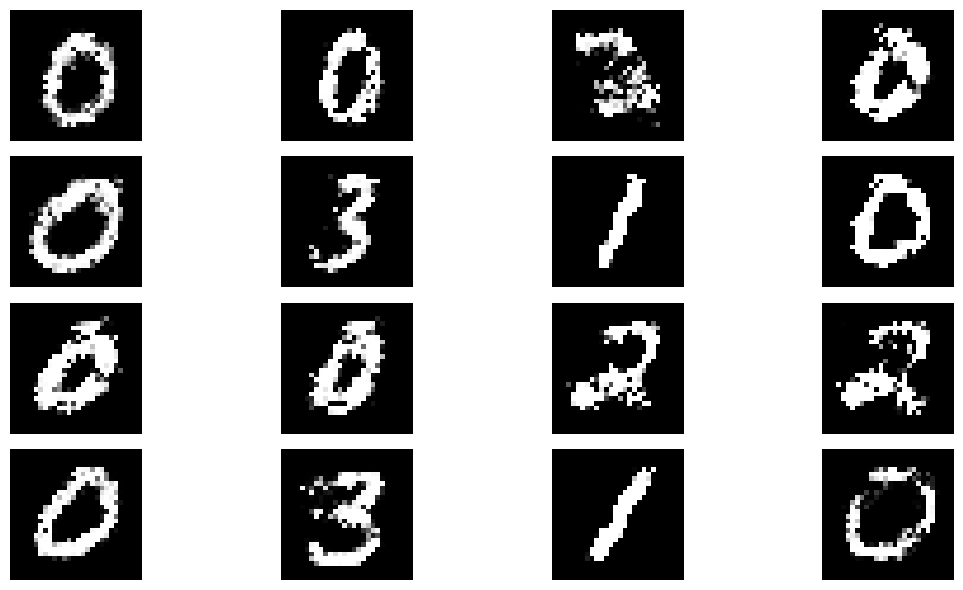

In [8]:
num_img = 16

fig, axes = plt.subplots(4, 4, figsize=(12, 6))
axes = axes.flatten()

# Sample from random normal
Z = np.random.randn(num_img, gan.generator.latent_dim)

# Pass through decoder to reconstruct
gan.generator.forward(Z)

# Generate and plot n images
for i in range(num_img):
    img = gan.generator.output[i].reshape(28, 28)  # Reshape the output to 28x28 image
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()